# Decision tree

1. Data Preparation:


Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("/content/drive/MyDrive/heart_disease.xlsx",sheet_name='Heart_disease')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4
907,57,Male,asymptomatic,142,277,True,st-t abnormality,182,FALSE,NaN,flat,normal,4


In [ ]:
df.shape

(908, 13)

2. Exploratory Data Analysis (EDA):


Perform exploratory data analysis to understand the structure of the dataset.

Check for missing values, outliers, and inconsistencies in the data.

Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [ ]:
# Missing values count
print(df.isnull().sum())



age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [ ]:
df['exang'] = df['exang'].replace({'TURE': True, 'FALSE': False})
df['exang'] = df['exang'].astype(bool)

#fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


/tmp/ipykernel_1311/1290652386.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].replace({'TURE': True, 'FALSE': False})


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [ ]:
#delete duplicate row
df.drop_duplicates(inplace=True)
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
Categorical Columns: Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


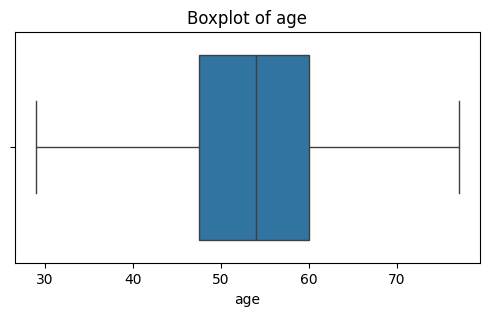

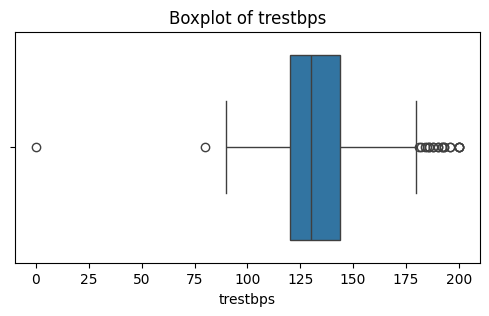

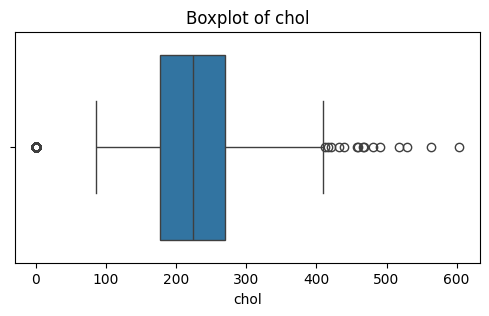

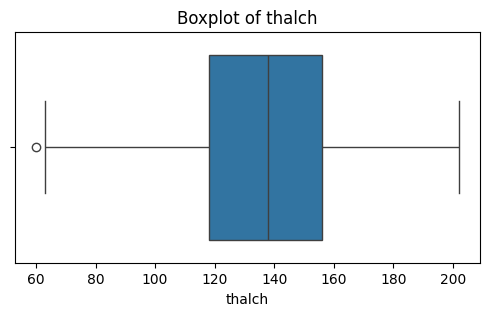

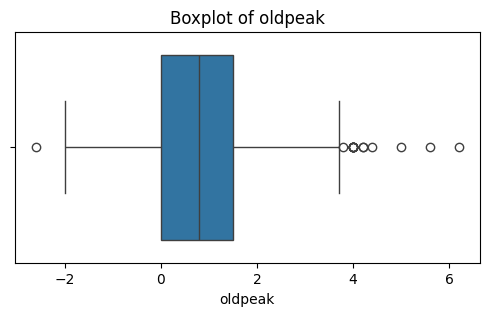

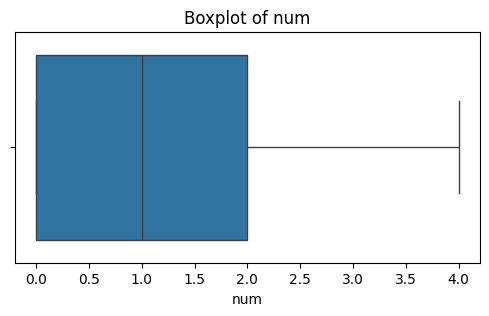

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

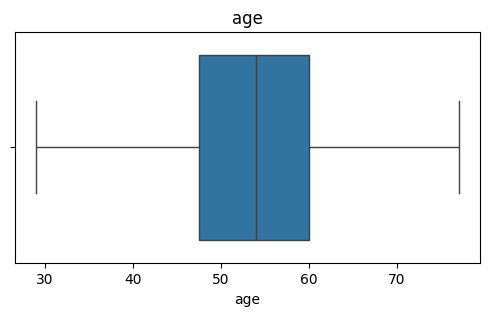

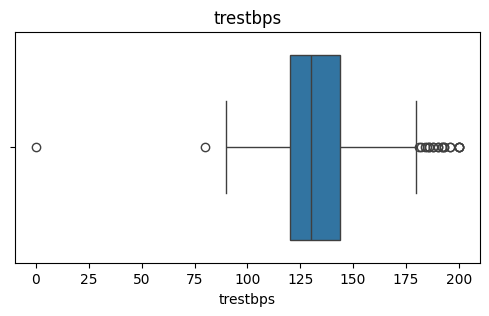

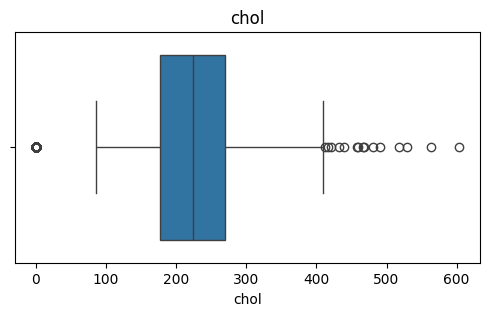

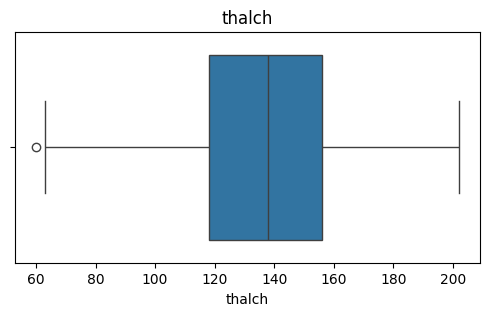

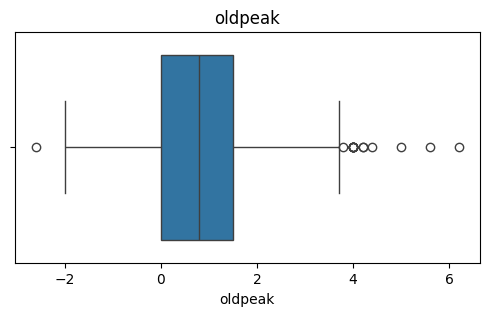

In [ ]:
numeric_cols = ['age','trestbps','chol','thalch','oldpeak']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df_corr = df.copy()

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

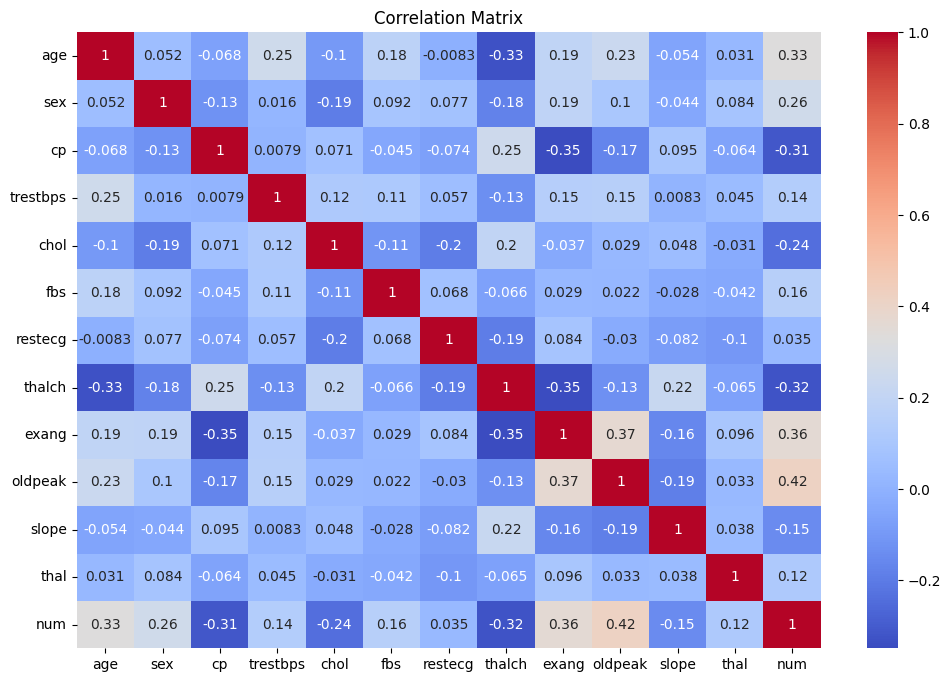

In [ ]:
#visualization
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [ ]:
print(df.select_dtypes(include='object').columns)

Index(['sex', 'cp', 'restecg', 'slope', 'thal'], dtype='object')


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex','cp','restecg','exang','slope','thal'],
    drop_first=True
)

In [ ]:
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).

Implement a Decision Tree Classification model using a library like scikit-learn.

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
#splitting data train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#model build and fitting model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred,average='weighted'))
print("Recall   :", recall_score(y_test,y_pred,average='weighted'))
print("F1 Score :", f1_score(y_test,y_pred,average='weighted'))

Accuracy : 0.4835164835164835
Precision: 0.5059840772830143
Recall   : 0.4835164835164835
F1 Score : 0.4912215515053971


In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.67      0.71        89
           1       0.34      0.43      0.38        47
           2       0.26      0.25      0.26        20
           3       0.10      0.12      0.11        17
           4       0.25      0.11      0.15         9

    accuracy                           0.48       182
   macro avg       0.34      0.32      0.32       182
weighted avg       0.51      0.48      0.49       182



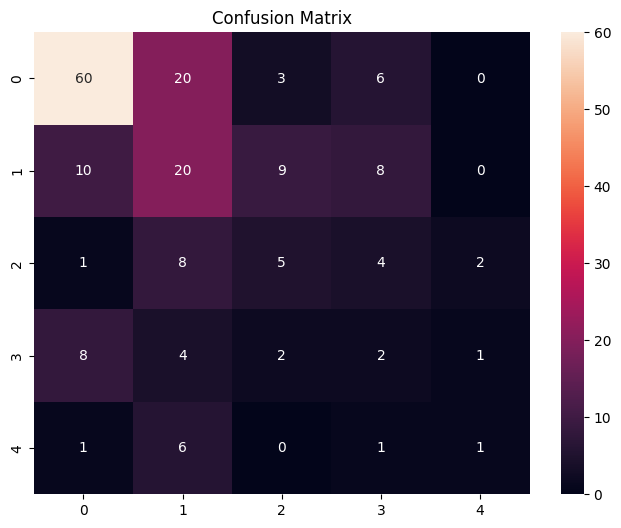

In [ ]:
#"Confusion Matrix"
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [ ]:
#grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [ ]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,y_pred_best))

Accuracy: 0.5274725274725275


6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features


In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

               Feature  Importance
12          exang_True    0.459926
2                 chol    0.239927
4               thalch    0.105585
7   cp_atypical angina    0.082583
0                  age    0.068262
1             trestbps    0.043717
3                  fbs    0.000000
6             sex_Male    0.000000
5              oldpeak    0.000000
8       cp_non-anginal    0.000000


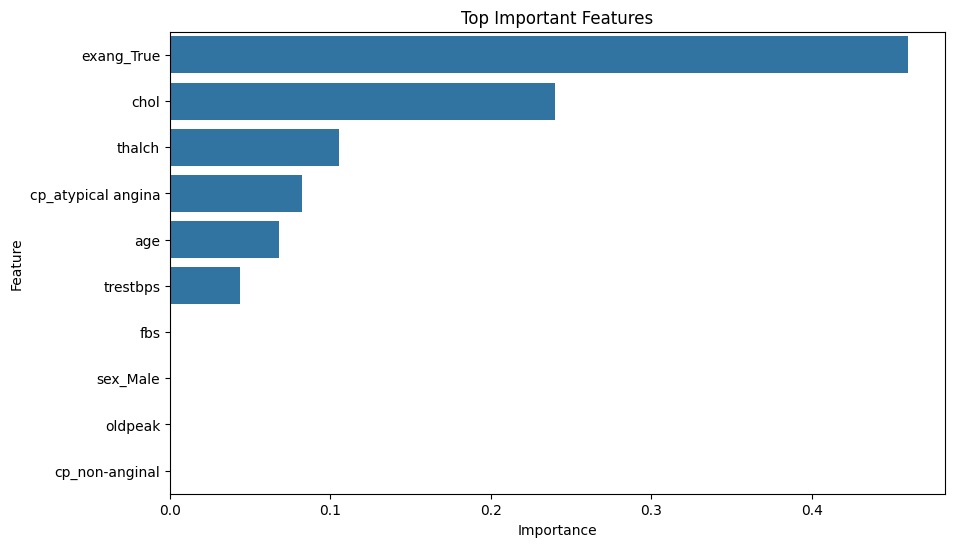

In [ ]:
#Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top Important Features")
plt.show()

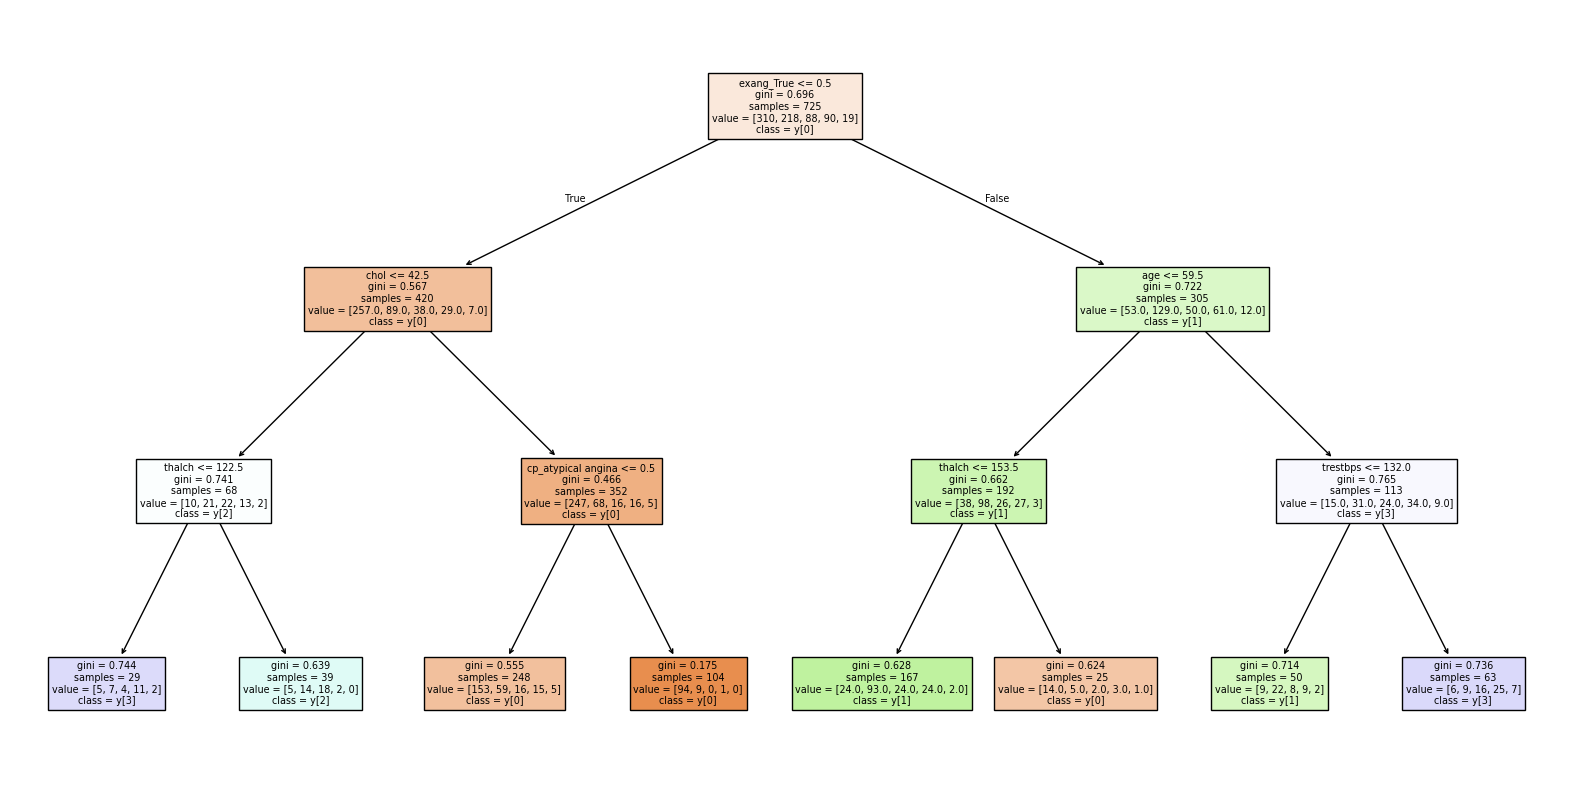

In [ ]:
#decision tree visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    filled=True,
    feature_names=X.columns,
    class_names=True
)

plt.show()

1. What are some common hyperparameters of Decision Tree models?
Hyperparameter

max_depth	Limits

min_samples_split

min_samples_leaf

criterion

max_features

**2.Difference Between Label Encoding and One-Hot Encoding**
| Label Encoding                   | One-Hot Encoding          |
| Converts categories into numbers | Creates binary columns    |
| Example: Male=0, Female=1        | Male=[1,0], Female=[0,1]  |
| Introduces ordinal relationship  | No ordinal relationship   |
| Suitable for ordinal data        | Suitable for nominal data |
| Uses less memory                 | Uses more memory          |
